<a href="https://colab.research.google.com/github/adawongHL/ML_project_F24/blob/main/supervised_logistic_regression_Version_2_(FINAL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#pip install liac-arff numpy pandas scikit-learn matplotlib seaborn

In [ ]:
'''
Changes from Version 1:
- Added helper functions. Code is now siginificantly more concise.
- Included metrics of testing the trained model on the TRAINING set
  - Useful for evluating under/overfitting
- TODO: test different learning rates (not strictly necessarily from PDF??)

Overview:
# Supervised Learning: Logistic Regression
## To-do
- [A] Setup
- [B] Data Pre-processing
- [C] Training
- [D] Evaluation
- [E] Visualization
- [F] Feature Transformations (at least 3 types)
- [G] Regularization (at least 6 values)
'''

'\nChanges from Version 1:\n- Added helper functions. Code is now siginificantly more concise.\n- Included metrics of testing the trained model on the TRAINING set\n  - Useful for evluating under/overfitting\n- TODO: test different learning rates (not strictly necessarily from PDF??)\n\nOverview:\n# Supervised Learning: Logistic Regression\n## To-do\n- [A] Setup\n- [B] Data Pre-processing\n- [C] Training\n- [D] Evaluation\n- [E] Visualization\n- [F] Feature Transformations (at least 3 types)\n- [G] Regularization (at least 6 values)\n'

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress FutureWarning globally
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
# helper functions
# Confusion Matrix Structure:
#             Predicted
#             0       1
# True   0   [ TN   FP ]
#        1   [ FN   TP ]

def get_recall(confusion_matrix):
  TN, FP, FN, TP = confusion_matrix.ravel() # returns 1D copy
  recall = TP / (TP + FN) if (TP + FN) != 0 else 0.0
  return round(recall,2)

def get_precision(confusion_matrix):
  TN, FP, FN, TP = confusion_matrix.ravel() # returns 1D copy
  precision = TP / (TP + FP) if (TP + FP) != 0 else 0.0
  return round(precision,2)

def visualize_ROC_plot(y_true, y_predict_prob, class_mapping=None, title='ROC Curve'):
  if class_mapping:
      y_true_numeric = y_true.replace(class_mapping)
  else:
      y_true_numeric = y_true

  # Compute ROC curve and AUC (area under curve)
  fpr, tpr, _ = metrics.roc_curve(y_true_numeric, y_predict_prob)
  auc = metrics.roc_auc_score(y_true_numeric, y_predict_prob)

  # Plot
  plt.figure()
  plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(title)
  plt.legend(loc='lower right')
  plt.show()

  return auc

def get_confusion_matrix(y_true, y_pred):
  cnf_matrix = metrics.confusion_matrix(y_true, y_pred)
  return cnf_matrix

def display_metrics(y_true, y_pred, cnf_matrix, target_names):
  print(metrics.classification_report(y_true, y_pred, target_names=target_names))
  accuracy = metrics.classification_report(y_true, y_pred, target_names=target_names)[219:223]
  print(f"Accuracy: {accuracy}")
  print(f"Recall: {get_recall(cnf_matrix)}")
  print(f"Precision: {get_precision(cnf_matrix)}")

def visualize_confusion_matrix(cnf_matrix, class_names, title="Confusion Matrix"):
  fig, ax = plt.subplots()
  tick_marks = np.arange(len(class_names))
  plt.xticks(tick_marks, class_names)
  plt.yticks(tick_marks, class_names)

  # Create heatmap using seaborn
  sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="coolwarm", fmt='g')
  ax.xaxis.set_label_position("top")
  plt.tight_layout()
  plt.title(title, y=1.05)  # y-coordinate for title
  plt.xlabel('Predicted label')
  ax.xaxis.set_label_position("bottom")
  plt.ylabel('True label')



In [ ]:
## [A] Setup: Load the dataset
with open('dataset_31_credit-g.arff', 'r') as file:
    data, metadata = arff.loadarff(file)

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Convert byte strings to strings in data entries
df = df.map(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# CHECK
# Display column names (all strs)
col_count = 0
for column in df.columns:
    col_count += 1
    # print(f"Column: {column}, Type: {type(column)}")
# print(f"Total Number of columns = {col_count}") # 20 input features; last column is "class" (true label)

# Display the first few rows
# print(f"Total number of data entries = {data.size}")
# print(df.head())

# SECTION [A] DONE ✅
# <------------------------------------------------------------------------------------------------------------------------>

## [B] Data preprocessing

# Check for missing values and drop them
# print(df.isnull().sum())
df = df.dropna()

# Strip and lowercase all column names for consistency
df.columns = [col.strip().lower() for col in df.columns]

# print(f"Columns before one-hot-encode: {df.columns}")
# print(f"Total Columns: {len(df.columns)}")

## ONE-HOT ENCODING (no natural order)
columns_to_one_hot_encode = ["credit_history", "purpose", "personal_status", "other_parties", "property_magnitude", "other_payment_plans", "housing", "own_telephone", "foreign_worker"]
columns_to_one_hot_encode = [col.strip().lower() for col in columns_to_one_hot_encode]
df = pd.get_dummies(df, columns=columns_to_one_hot_encode)
# print(f"Columns after one-hot-encode: {df.columns}")
# print(f"Total Columns: {len(df.columns)}")

# ORDINAL ENCODING (with natural order)
columns_for_ordinal_encoding = ["checking_status", "savings_status", "employment", "job"]
columns_for_ordinal_encoding = [col.strip().lower() for col in columns_for_ordinal_encoding]
# Ordinal Encoding (Custom)
# Note: Not using OrdinalEncode() because it assigns arbitrarily-ordered values for ordinal columns

# checking_status order
checking_status_mapping = {
    'no checking': 0,
    '<0': 1,
    '0<=X<200': 2,
    '>=200': 3,
}
df['checking_status'] = df['checking_status'].replace(checking_status_mapping)
# print(df['checking_status'].head())

# savings_status order
savings_status_mapping = {
    'no known savings': 0,
    '<100': 1,
    '100<=X<500': 2,
    '500<=X<1000': 3,
    '>=1000': 4
}
df['savings_status'] = df['savings_status'].replace(savings_status_mapping)

# employment order
employment_mapping = {
    'unemployed': 0,
    '<1': 1,
    '1<=X<4': 2,
    '4<=X<7': 3,
    '>=7': 4
}
df['employment'] = df['employment'].replace(employment_mapping)

# job order
job_mapping = {
    'unemp/unskilled non res': 0,
    'unskilled resident': 1,
    'skilled': 2,
    'high qualif/self emp/mgmt': 3
}
df['job'] = df['job'].replace(job_mapping)

# CHECK
# print("Categorical variables encoded! Before standardizing......")
# print(df['job'].head(5))


## STANDARDIZATION (change values s.t. mean=0, var=1 for all numerical and ordinal columns)
# Note: Exclude one-hot encoded columns and true label column
one_hot_encoded_columns = [col for col in df.columns if any(prefix in col for prefix in columns_to_one_hot_encode)]
X_to_scale = df.drop(one_hot_encoded_columns + ['class'], axis=1)
y = df['class']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_to_scale)

# Convert scaled_data back to DataFrame
scaled_data = pd.DataFrame(scaled_data, columns=X_to_scale.columns)

# Combine scaled data with one-hot encoded columns
scaled_X = pd.concat([scaled_data, df[one_hot_encoded_columns]], axis=1) # true label column excluded
# print("After standardizing data......")
# print(scaled_X['job'].head(5))
# print(y.head())
# print(type(y))
# print(type(scaled_X))

# Notes:
# "scaled_X" contains input data (standardized and encoded); we will split "scaled_X" for training, validation and testing
# "y" contains true labels

## SPLIT THE DATASET
# 80/10/10% for training, validation and test sets
# First split: 80% training, 20% remaining
X_train, X_temp, y_train, y_temp = train_test_split(scaled_X, y, test_size=0.2, random_state=42)

# Second split: 50% of the remaining 20% for validation and test (10% each of the original dataset)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Verify set sizes
print("Training set size:", X_train.shape, y_train.shape) # use for initial training of model
print("Validation set size:", X_val.shape, y_val.shape) # use for tuning regularization hyperparameters
print("Test set size:", X_test.shape, y_test.shape) # use for final evaluation of model performance

# SECTION [B] DONE ✅

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_31_credit-g.arff'

In [ ]:
## [C] Training: Logistic Regression (no regularization)
# use "lbfgs" solver (optimization algo) bc it can support no regularization unlike other solvers
logreg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
logreg.fit(X_train, y_train)    # train the model on our training set; computes best weights to minimize -ve log-likelihood function
y_predict = logreg.predict(X_test)  # make predictions on test set (to calculate test accuracy)
y_predict_train = logreg.predict(X_train)  # make predictions on training set (to calculate training accuracy)
# print(type(y_test))
# print(type(y_predict[0]))
# print(type(y_test.iloc[0]))
# SECTION [C] DONE ✅

In [ ]:
## [D] Evaluation: use test set
# Confusion Matrix
cnf_matrix = get_confusion_matrix(y_test, y_predict)
cnf_matrix_train = get_confusion_matrix(y_train, y_predict_train)

# Structure of Confusion Matrix:
# * Top-left-bottom-right Diagonal = correct predictions
# * 0 for "bad", 1 for "good" credit risk
#             Predicted
#             0       1
# True   0   [ TN   FP ]
#        1   [ FN   TP ]

# Evaluation Metrics
target_names = ['bad credit risk', 'good credit risk']
print("Metrics on test set:")
print(f"Confusion Matrix (on test set):\n {cnf_matrix}")
display_metrics(y_test, y_predict, cnf_matrix, target_names=target_names)

print("--------------------------------------------------------")

print("Metrics on training set:")
print(f"Confusion Matrix (on training set):\n {cnf_matrix_train}")
display_metrics(y_train, y_predict_train, cnf_matrix_train, target_names=target_names)

# Accuracy = proportion of correct predictions
# Precision = proportion of true pos among everything predicted true = (TP) / (TP + FP)
# Recall = proportion of true pos among everything actually true = (TP) / (TP + FN)

# SECTION [D] DONE ✅

Metrics on test set:
Confusion Matrix (on test set):
 [[ 7 21]
 [10 62]]
                  precision    recall  f1-score   support

 bad credit risk       0.41      0.25      0.31        28
good credit risk       0.75      0.86      0.80        72

        accuracy                           0.69       100
       macro avg       0.58      0.56      0.56       100
    weighted avg       0.65      0.69      0.66       100

Accuracy: 0.69
Recall: 0.86
Precision: 0.75
--------------------------------------------------------
Metrics on training set:
Confusion Matrix (on training set):
 [[107 134]
 [ 56 503]]
                  precision    recall  f1-score   support

 bad credit risk       0.66      0.44      0.53       241
good credit risk       0.79      0.90      0.84       559

        accuracy                           0.76       800
       macro avg       0.72      0.67      0.69       800
    weighted avg       0.75      0.76      0.75       800

Accuracy: 0.76
Recall: 0.9
Precision: 0

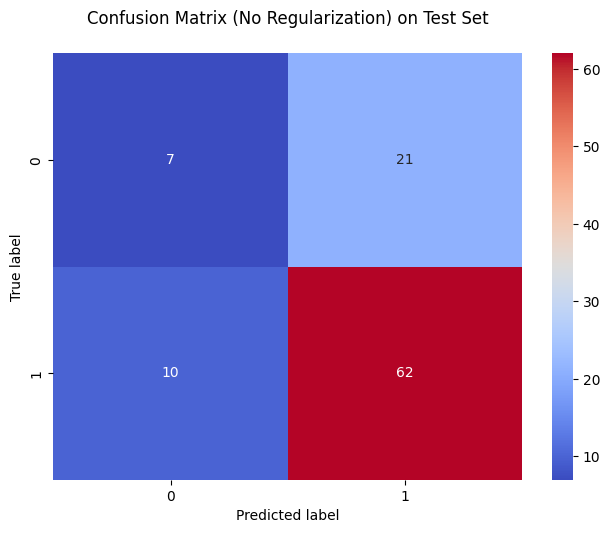

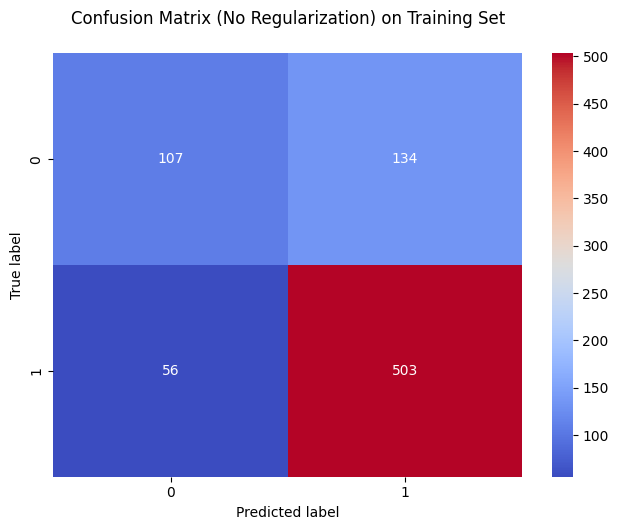

In [ ]:
## [E] Visualization
# Confusion Matrices
class_names=[0,1]

visualize_confusion_matrix(cnf_matrix, class_names, "Confusion Matrix (No Regularization) on Test Set")
visualize_confusion_matrix(cnf_matrix_train, class_names, "Confusion Matrix (No Regularization) on Training Set")

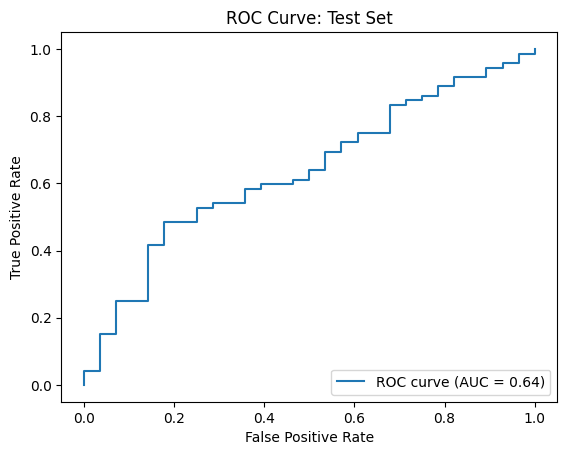

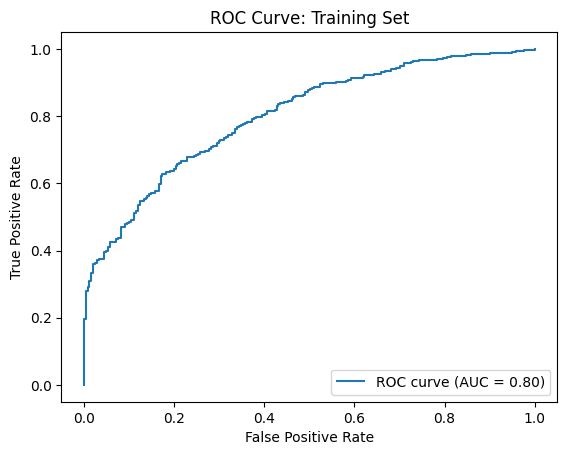

0.801475664160215

In [ ]:
# [E] Visualization - continued
# ROC Curve: how good is a binary-classifier model?
# For different threshold values, graph their...
# x-axis: false positive rate
# y-axis: true positive rate
# auc = area under curve; 1 indicates perfect classifier; < 0.5 is bad (worse than random guessing)

class_mapping = {'bad': 0, 'good': 1}
y_predict_prob = logreg.predict_proba(X_test)[::,1]
y_predict_prob_train = logreg.predict_proba(X_train)[::,1]

visualize_ROC_plot(y_test, y_predict_prob, class_mapping=class_mapping, title="ROC Curve: Test Set")
visualize_ROC_plot(y_train, y_predict_prob_train, class_mapping=class_mapping, title="ROC Curve: Training Set")

# SECTION [E] DONE ✅

Number of features after Polynomial transformation: 19600
Metrics on test set:
Confusion Matrix (on test set):
 [[16 12]
 [11 61]]
                  precision    recall  f1-score   support

 bad credit risk       0.59      0.57      0.58        28
good credit risk       0.84      0.85      0.84        72

        accuracy                           0.77       100
       macro avg       0.71      0.71      0.71       100
    weighted avg       0.77      0.77      0.77       100

Accuracy: 0.77
Recall: 0.85
Precision: 0.84
Metrics on training set:
Confusion Matrix (on training set):
 [[241   0]
 [  0 559]]
                  precision    recall  f1-score   support

 bad credit risk       1.00      1.00      1.00       241
good credit risk       1.00      1.00      1.00       559

        accuracy                           1.00       800
       macro avg       1.00      1.00      1.00       800
    weighted avg       1.00      1.00      1.00       800

Accuracy: 1.00
Recall: 1.0
Precision: 

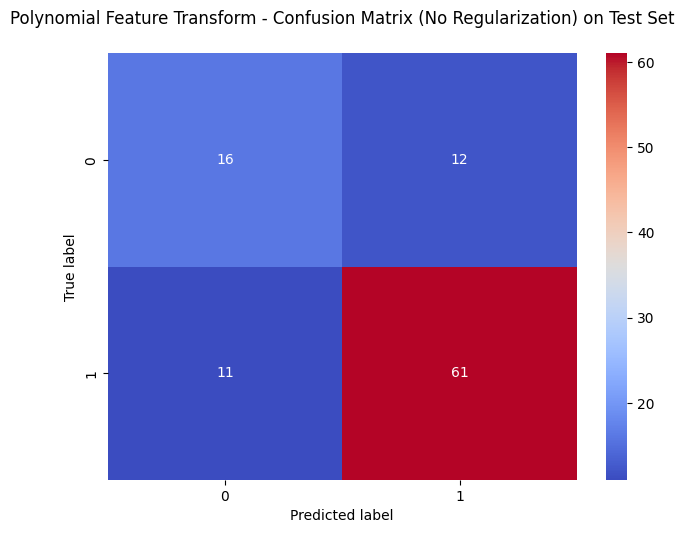

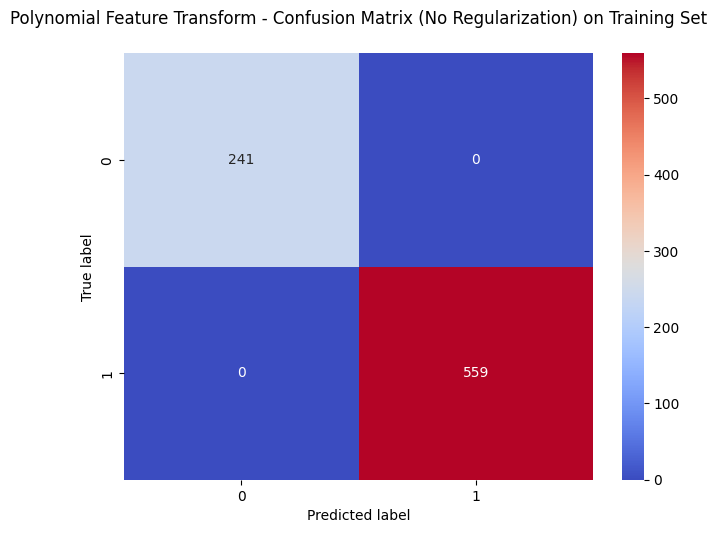

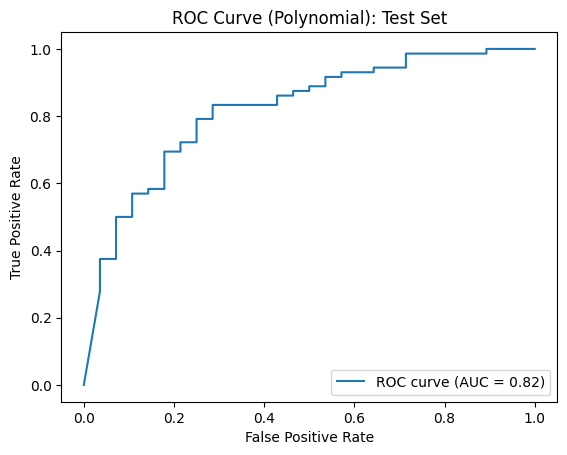

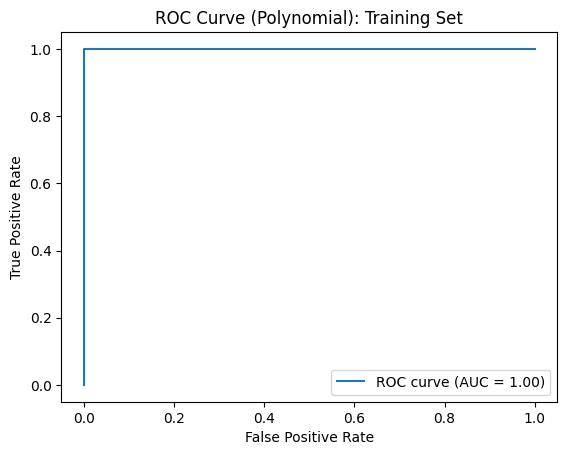

1.0

In [ ]:
## [F] Feature Transformations (at least 3 types)
# [F1] Polynomial transform, degree 3
# Train model
from sklearn.preprocessing import PolynomialFeatures

# Polynomial feature transformation
poly = PolynomialFeatures(degree=3)
X_train_polynomial = poly.fit_transform(X_train)
X_test_polynomial = poly.transform(X_test)
print(f"Number of features after Polynomial transformation: {X_train_polynomial.shape[1]}")

# Train logistic regression model on polynomial features
logreg_polynomial = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
logreg_polynomial.fit(X_train_polynomial, y_train)

# Make predictions on the test set
y_predict_polynomial = logreg_polynomial.predict(X_test_polynomial)
y_predict_polynomial_train = logreg_polynomial.predict(X_train_polynomial)

# Confusion Matrix
cnf_matrix_polynomial = get_confusion_matrix(y_test, y_predict_polynomial)
visualize_confusion_matrix(cnf_matrix_polynomial, class_names=[0, 1], title='Polynomial Feature Transform - Confusion Matrix (No Regularization) on Test Set')
cnf_matrix_polynomial_train = get_confusion_matrix(y_train, y_predict_polynomial_train)
visualize_confusion_matrix(cnf_matrix_polynomial_train, class_names=[0, 1], title='Polynomial Feature Transform - Confusion Matrix (No Regularization) on Training Set')

# Evaluation Metrics
target_names = ['bad credit risk', 'good credit risk']
print("Metrics on test set:")
print(f"Confusion Matrix (on test set):\n {cnf_matrix_polynomial}")
display_metrics(y_test, y_predict_polynomial, cnf_matrix_polynomial, target_names=target_names)

print("Metrics on training set:")
print(f"Confusion Matrix (on training set):\n {cnf_matrix_polynomial_train}")
display_metrics(y_train, y_predict_polynomial_train, cnf_matrix_polynomial_train, target_names=target_names)

# ROC Curve
class_mapping = {'bad': 0, 'good': 1}
y_predict_prob = logreg_polynomial.predict_proba(X_test_polynomial)[::,1]
y_predict_prob_train = logreg_polynomial.predict_proba(X_train_polynomial)[::,1]

visualize_ROC_plot(y_test, y_predict_prob, class_mapping=class_mapping, title="ROC Curve (Polynomial): Test Set")
visualize_ROC_plot(y_train, y_predict_prob_train, class_mapping=class_mapping, title="ROC Curve (Polynomial): Training Set")

Number of features after PCA transformation: 23
Metrics on test set:
                  precision    recall  f1-score   support

 bad credit risk       0.39      0.25      0.30        28
good credit risk       0.74      0.85      0.79        72

        accuracy                           0.68       100
       macro avg       0.57      0.55      0.55       100
    weighted avg       0.64      0.68      0.66       100

Accuracy: 0.68
Recall: 0.85
Precision: 0.74
Metrics on training set:
                  precision    recall  f1-score   support

 bad credit risk       0.62      0.35      0.45       241
good credit risk       0.76      0.91      0.83       559

        accuracy                           0.74       800
       macro avg       0.69      0.63      0.64       800
    weighted avg       0.72      0.74      0.71       800

Accuracy: 0.74
Recall: 0.91
Precision: 0.76


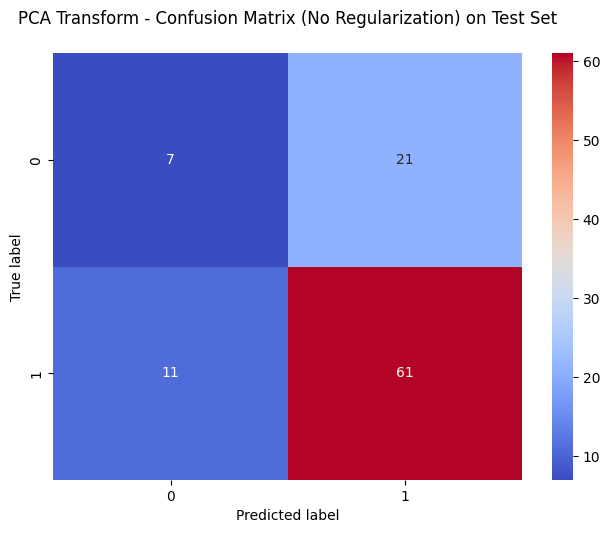

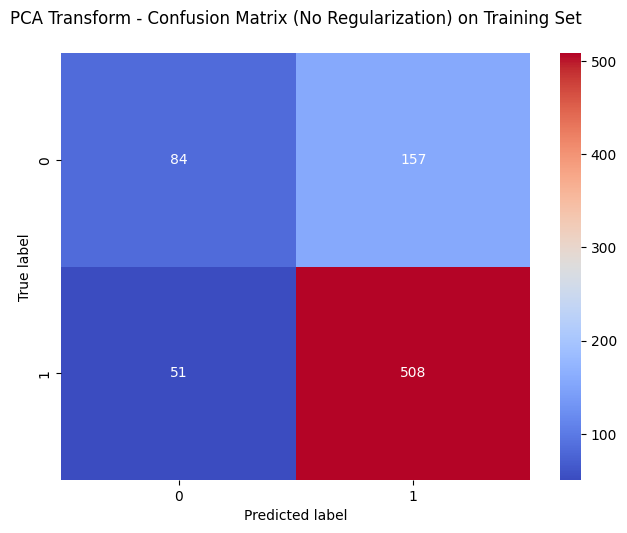

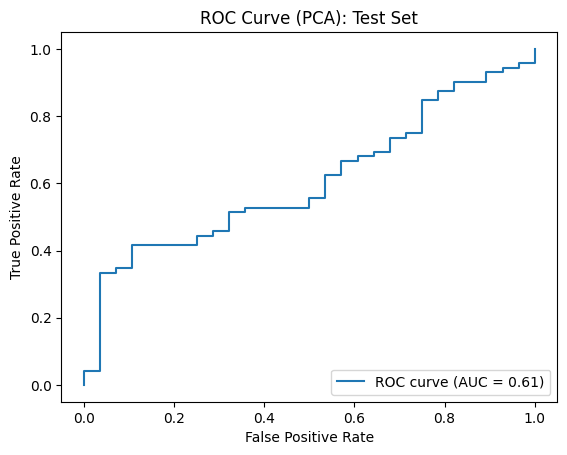

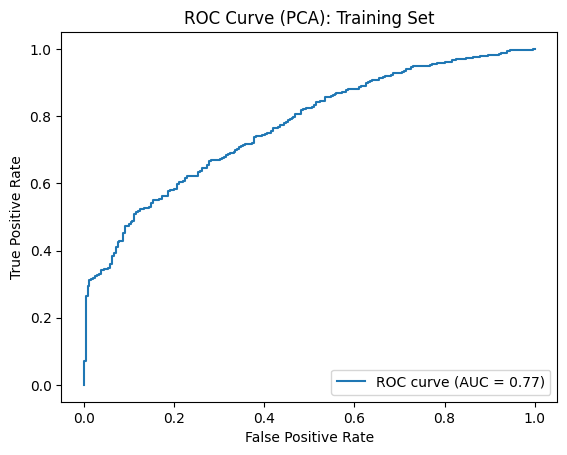

0.769238192088718

In [ ]:
# [F2] PCA (principal component analysis)
# Train model with PCA transformation
from sklearn.decomposition import PCA

# Initialize PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance in the data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Number of features after PCA transformation
print(f"Number of features after PCA transformation: {X_train_pca.shape[1]}")

# Train logistic regression model on PCA-transformed features
logreg_pca = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
logreg_pca.fit(X_train_pca, y_train)

# Make predictions on the test and training set
y_predict_pca = logreg_pca.predict(X_test_pca)
y_predict_pca_train = logreg_pca.predict(X_train_pca)

# Confusion Matrix for test set
cnf_matrix_pca = get_confusion_matrix(y_test, y_predict_pca)
visualize_confusion_matrix(cnf_matrix_pca, class_names=[0, 1], title='PCA Transform - Confusion Matrix (No Regularization) on Test Set')

# Confusion Matrix for training set
cnf_matrix_pca_train = get_confusion_matrix(y_train, y_predict_pca_train)
visualize_confusion_matrix(cnf_matrix_pca_train, class_names=[0, 1], title='PCA Transform - Confusion Matrix (No Regularization) on Training Set')

# Evaluation Metrics for test set
target_names = ['bad credit risk', 'good credit risk']
print("Metrics on test set:")
display_metrics(y_test, y_predict_pca, cnf_matrix_pca, target_names=target_names)

# Evaluation Metrics for training set
print("Metrics on training set:")
display_metrics(y_train, y_predict_pca_train, cnf_matrix_pca_train, target_names=target_names)

# ROC Curve for test set
class_mapping = {'bad': 0, 'good': 1}
y_predict_prob_pca = logreg_pca.predict_proba(X_test_pca)[::,1]
y_predict_prob_pca_train = logreg_pca.predict_proba(X_train_pca)[::,1]

visualize_ROC_plot(y_test, y_predict_prob_pca, class_mapping=class_mapping, title="ROC Curve (PCA): Test Set")
visualize_ROC_plot(y_train, y_predict_prob_pca_train, class_mapping=class_mapping, title="ROC Curve (PCA): Training Set")

Metrics on test set:
                  precision    recall  f1-score   support

 bad credit risk       0.62      0.46      0.53        28
good credit risk       0.81      0.89      0.85        72

        accuracy                           0.77       100
       macro avg       0.71      0.68      0.69       100
    weighted avg       0.76      0.77      0.76       100

Accuracy: 0.77
Recall: 0.89
Precision: 0.81
Metrics on training set:
                  precision    recall  f1-score   support

 bad credit risk       1.00      1.00      1.00       241
good credit risk       1.00      1.00      1.00       559

        accuracy                           1.00       800
       macro avg       1.00      1.00      1.00       800
    weighted avg       1.00      1.00      1.00       800

Accuracy: 1.00
Recall: 1.0
Precision: 1.0


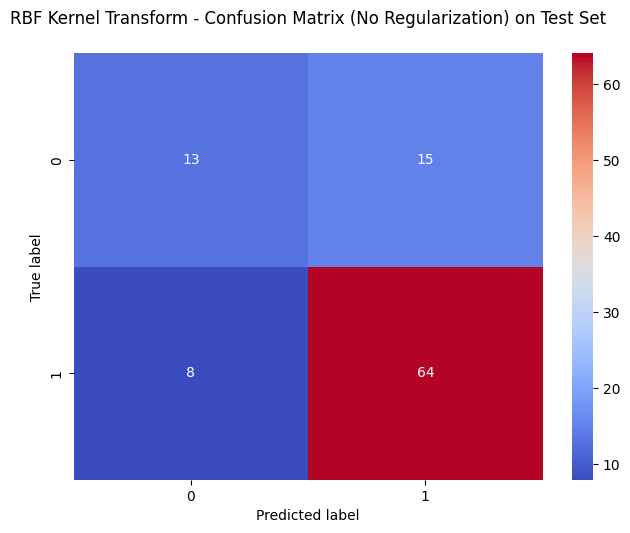

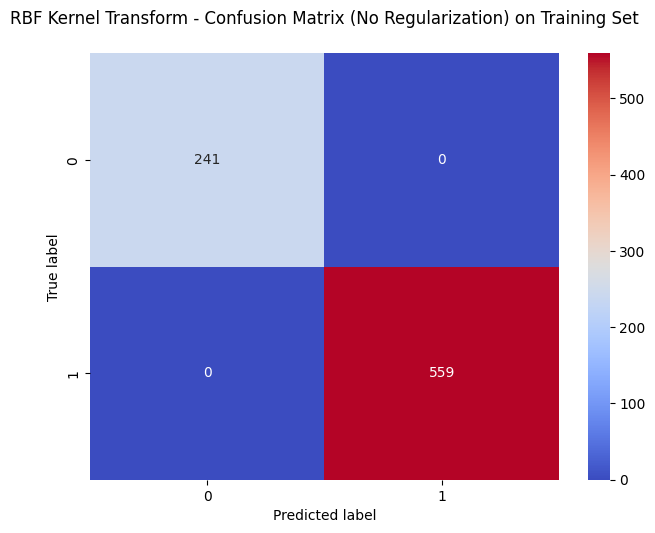

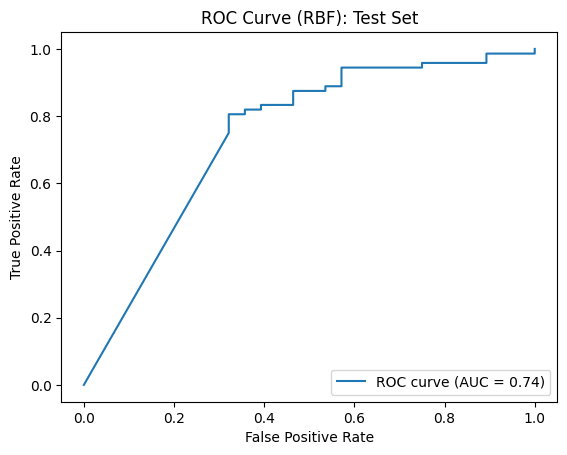

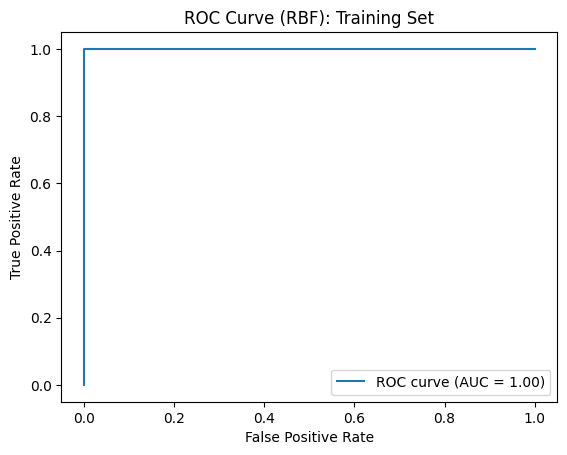

1.0

In [ ]:
# [F3] Radial-Basis Function Kernel Transform (RBF)
from sklearn.metrics.pairwise import rbf_kernel

# Gamma parameter for RBF kernel
gamma = 0.1

# Apply RBF kernel
X_train_rbf = rbf_kernel(X_train, X_train, gamma=gamma)  # RBF kernel on training data
X_test_rbf = rbf_kernel(X_test, X_train, gamma=gamma)  # RBF kernel between test and training data

# Train logistic regression model on RBF-transformed features
logreg_rbf = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
logreg_rbf.fit(X_train_rbf, y_train)

# Make predictions on the test and training set
y_predict_rbf = logreg_rbf.predict(X_test_rbf)
y_predict_rbf_train = logreg_rbf.predict(X_train_rbf)

# Confusion Matrix for test set
cnf_matrix_rbf = get_confusion_matrix(y_test, y_predict_rbf)
visualize_confusion_matrix(cnf_matrix_rbf, class_names=[0, 1], title='RBF Kernel Transform - Confusion Matrix (No Regularization) on Test Set')

# Confusion Matrix for training set
cnf_matrix_rbf_train = get_confusion_matrix(y_train, y_predict_rbf_train)
visualize_confusion_matrix(cnf_matrix_rbf_train, class_names=[0, 1], title='RBF Kernel Transform - Confusion Matrix (No Regularization) on Training Set')

# Evaluation Metrics for test set
target_names = ['bad credit risk', 'good credit risk']
print("Metrics on test set:")
display_metrics(y_test, y_predict_rbf, cnf_matrix_rbf, target_names=target_names)

# Evaluation Metrics for training set
print("Metrics on training set:")
display_metrics(y_train, y_predict_rbf_train, cnf_matrix_rbf_train, target_names=target_names)

# ROC Curve for test set
class_mapping = {'bad': 0, 'good': 1}
y_predict_prob_rbf = logreg_rbf.predict_proba(X_test_rbf)[::, 1]
y_predict_prob_rbf_train = logreg_rbf.predict_proba(X_train_rbf)[::, 1]

visualize_ROC_plot(y_test, y_predict_prob_rbf, class_mapping=class_mapping, title="ROC Curve (RBF): Test Set")
visualize_ROC_plot(y_train, y_predict_prob_rbf_train, class_mapping=class_mapping, title="ROC Curve (RBF): Training Set")

---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 1e-06..................
Metrics on validation set:
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00        31
good credit risk       0.69      1.00      0.82        69

        accuracy                           0.69       100
       macro avg       0.34      0.50      0.41       100
    weighted avg       0.48      0.69      0.56       100

Accuracy: 0.69
Recall: 1.0
Precision: 0.69
Metrics on training set:
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00       241
good credit risk       0.70      1.00      0.82       559

        accuracy                           0.70       800
       macro avg       0.35      0.50      0.41       800
    weighted avg       0.49      0.70      0.57       800

Accuracy: 0.70
Recall: 1.0
Precision: 0.7


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

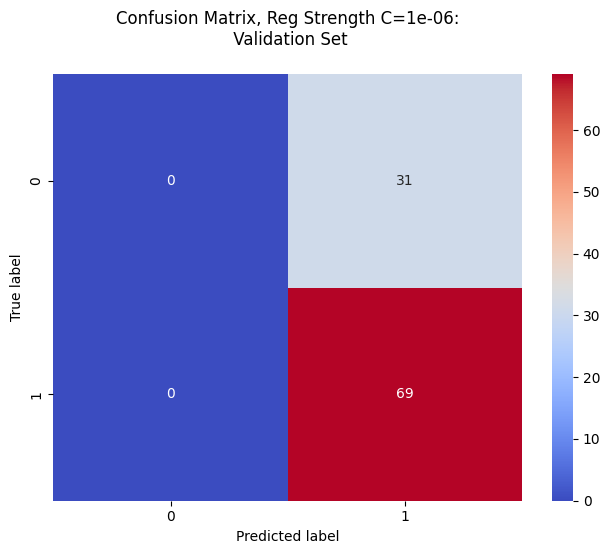

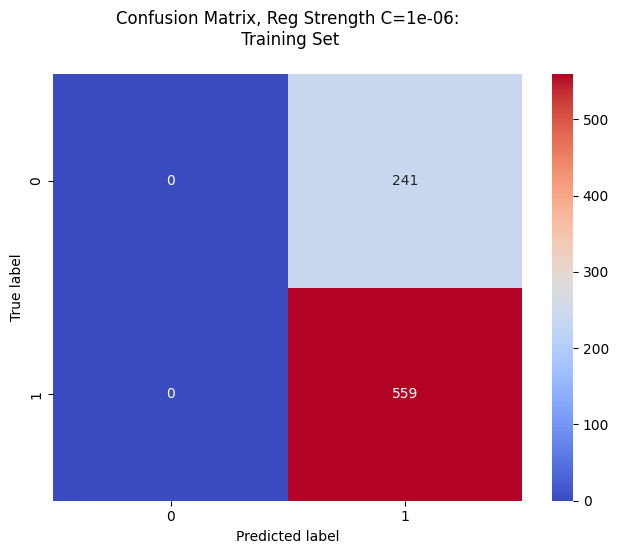

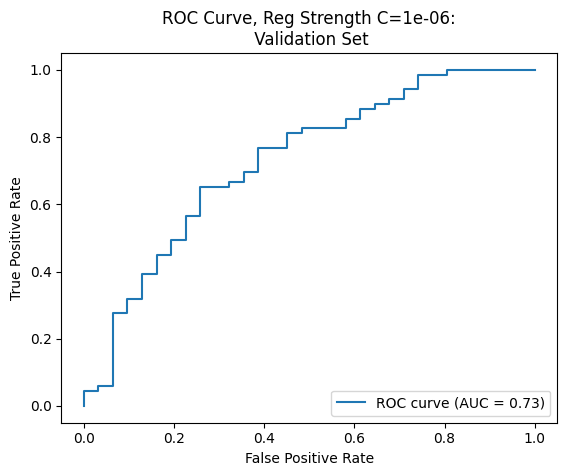

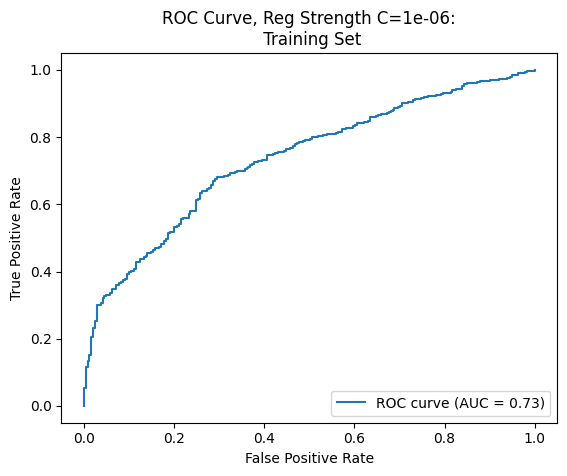

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 0.0001..................
Metrics on validation set:
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00        31
good credit risk       0.69      1.00      0.82        69

        accuracy                           0.69       100
       macro avg       0.34      0.50      0.41       100
    weighted avg       0.48      0.69      0.56       100

Accuracy: 0.69
Recall: 1.0
Precision: 0.69
Metrics on training set:
                  precision    recall  f1-score   support

 bad credit risk       0.00      0.00      0.00       241
good credit risk       0.70      1.00      0.82       559

        accuracy                           0.70       800
       macro avg       0.35      0.50      0.41       800
    weighted avg       0.49      0.70      0.57       

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

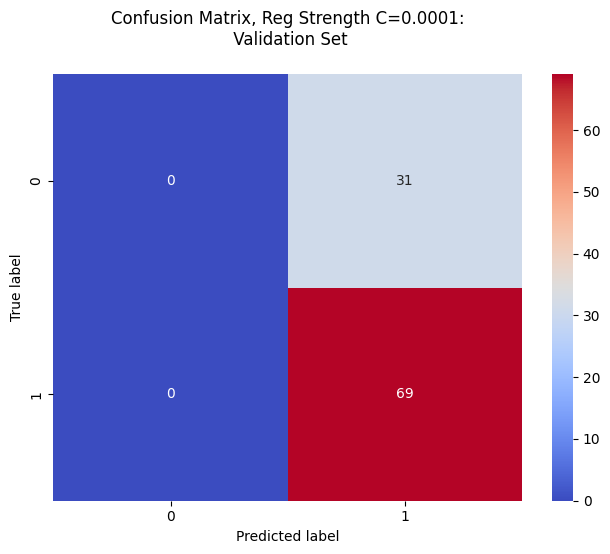

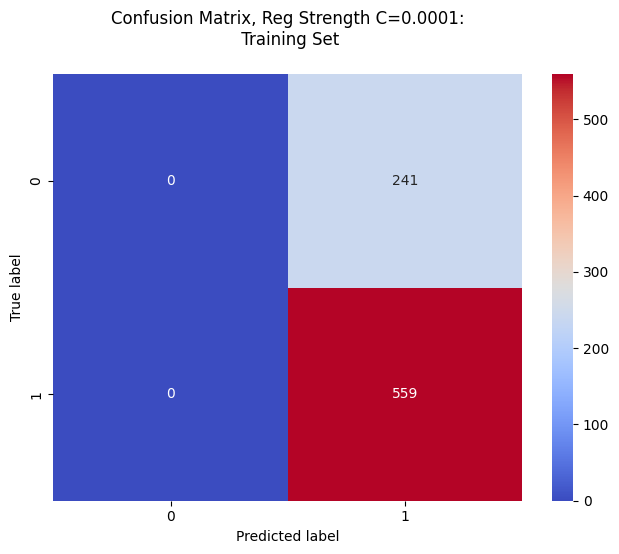

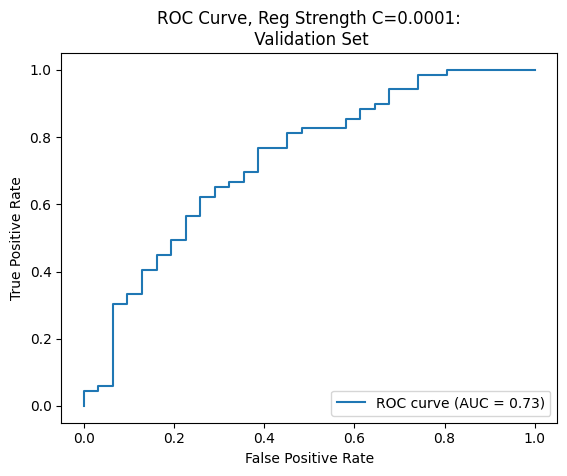

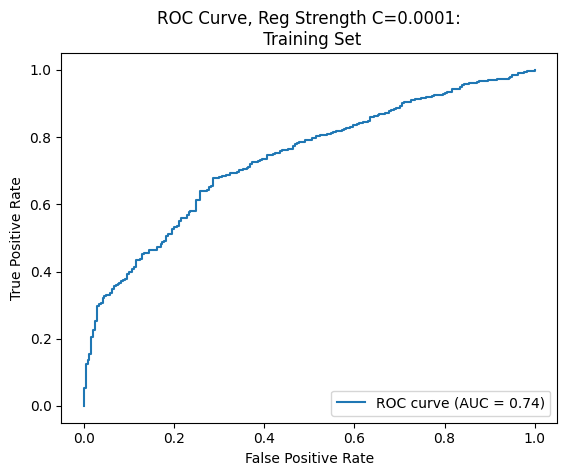

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 0.01..................
Metrics on validation set:
                  precision    recall  f1-score   support

 bad credit risk       1.00      0.23      0.37        31
good credit risk       0.74      1.00      0.85        69

        accuracy                           0.76       100
       macro avg       0.87      0.61      0.61       100
    weighted avg       0.82      0.76      0.70       100

Accuracy: 0.76
Recall: 1.0
Precision: 0.74
Metrics on training set:
                  precision    recall  f1-score   support

 bad credit risk       0.67      0.13      0.22       241
good credit risk       0.72      0.97      0.83       559

        accuracy                           0.72       800
       macro avg       0.70      0.55      0.52       800
    weighted avg       0.71      0.72      0.64       80

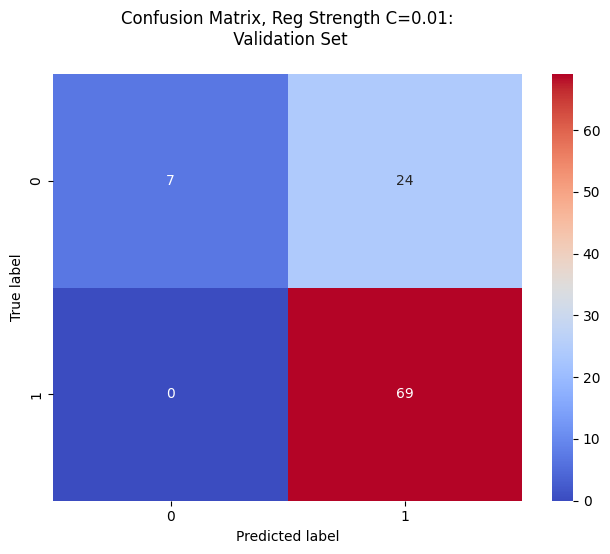

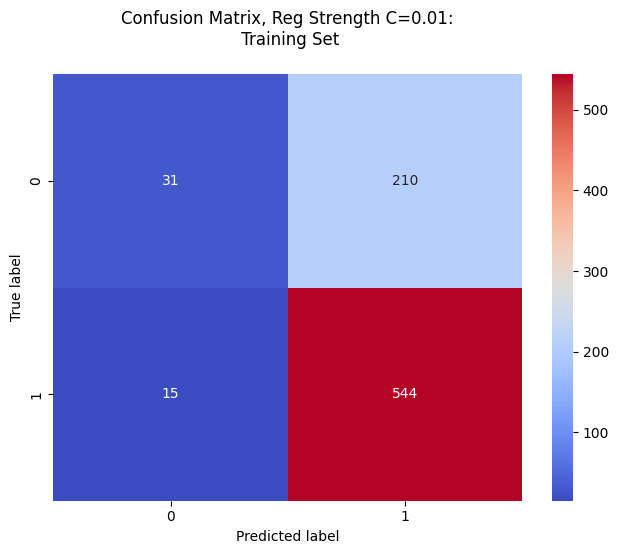

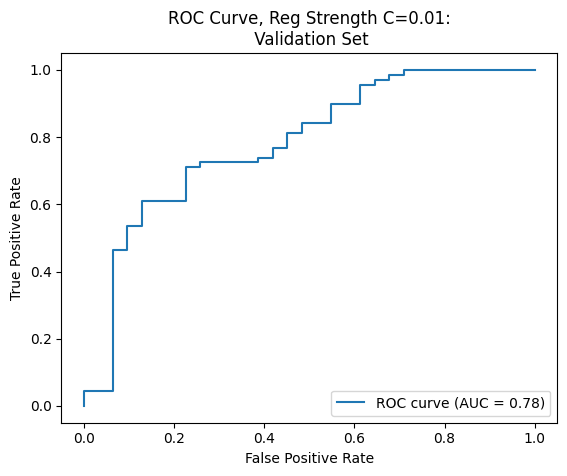

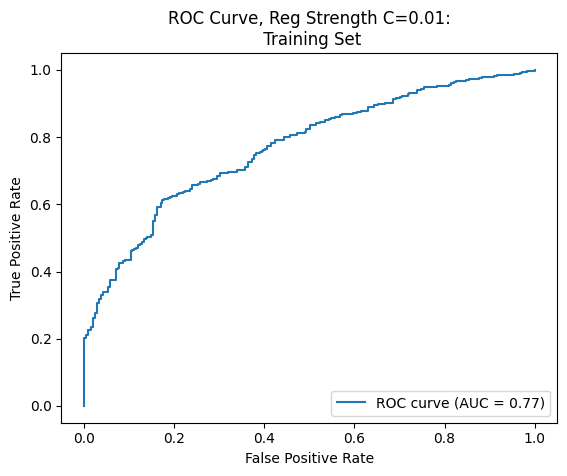

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 1..................
Metrics on validation set:
                  precision    recall  f1-score   support

 bad credit risk       0.75      0.48      0.59        31
good credit risk       0.80      0.93      0.86        69

        accuracy                           0.79       100
       macro avg       0.78      0.71      0.72       100
    weighted avg       0.78      0.79      0.78       100

Accuracy: 0.79
Recall: 0.93
Precision: 0.8
Metrics on training set:
                  precision    recall  f1-score   support

 bad credit risk       0.66      0.42      0.52       241
good credit risk       0.78      0.91      0.84       559

        accuracy                           0.76       800
       macro avg       0.72      0.66      0.68       800
    weighted avg       0.75      0.76      0.74       800



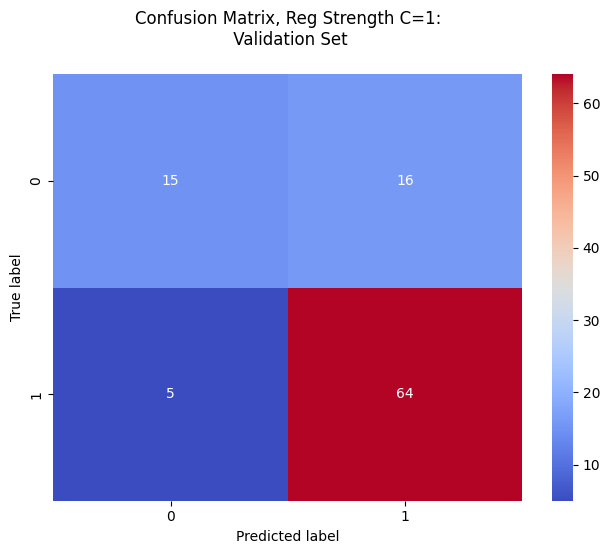

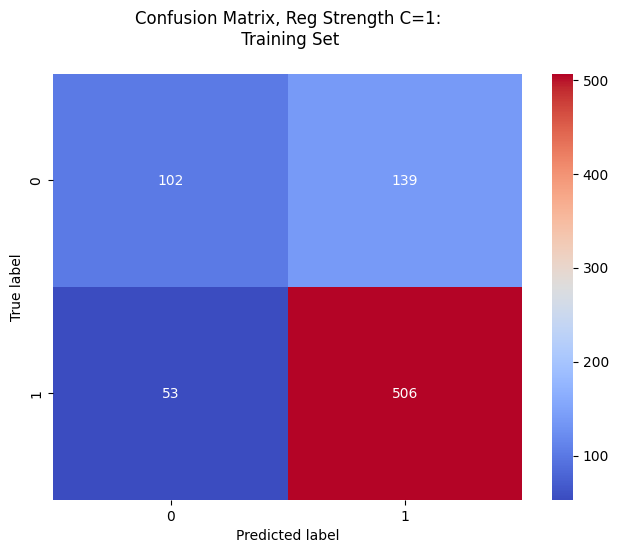

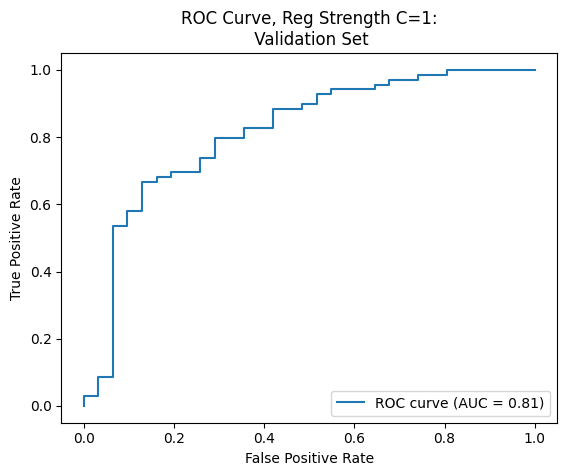

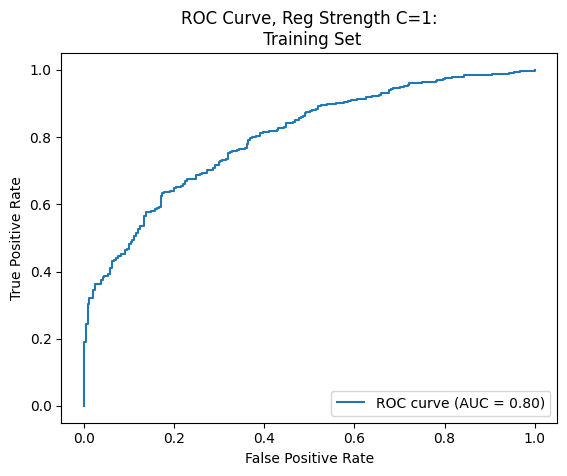

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 100..................
Metrics on validation set:
                  precision    recall  f1-score   support

 bad credit risk       0.71      0.48      0.58        31
good credit risk       0.80      0.91      0.85        69

        accuracy                           0.78       100
       macro avg       0.76      0.70      0.71       100
    weighted avg       0.77      0.78      0.77       100

Accuracy: 0.78
Recall: 0.91
Precision: 0.8
Metrics on training set:
                  precision    recall  f1-score   support

 bad credit risk       0.66      0.44      0.53       241
good credit risk       0.79      0.90      0.84       559

        accuracy                           0.76       800
       macro avg       0.72      0.67      0.69       800
    weighted avg       0.75      0.76      0.75       800

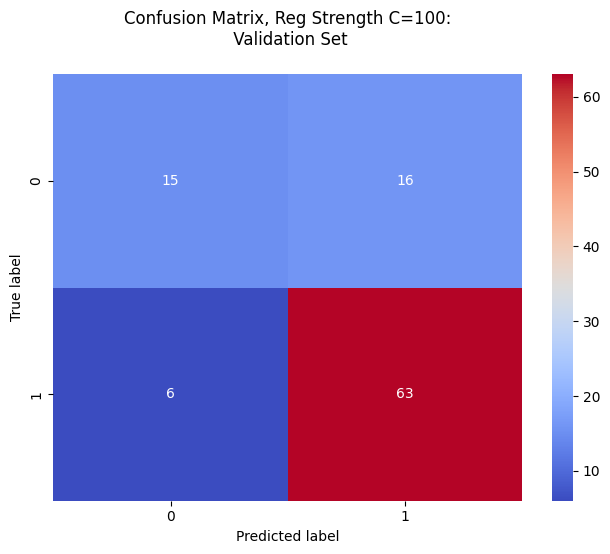

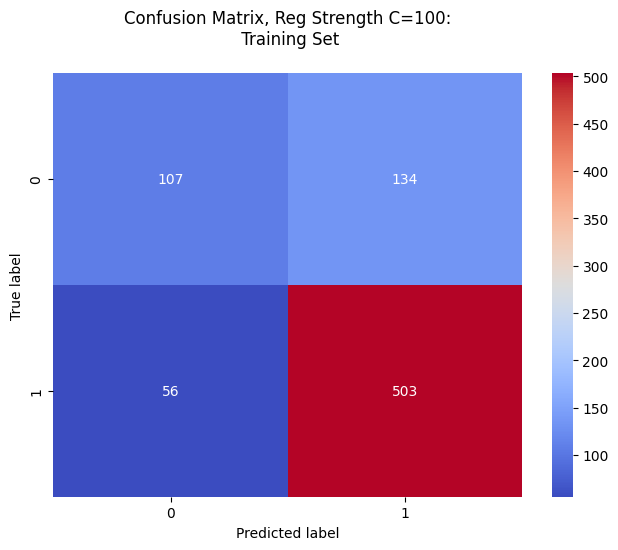

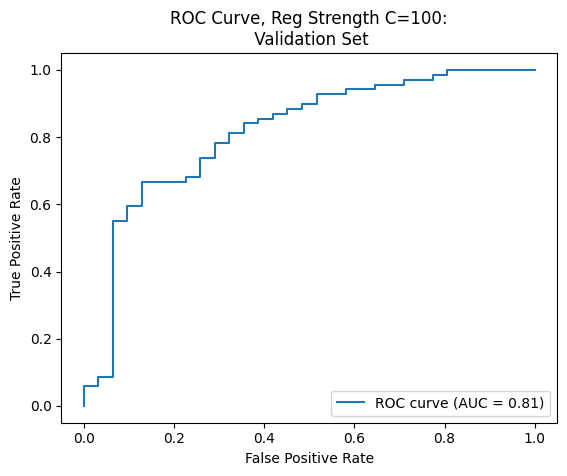

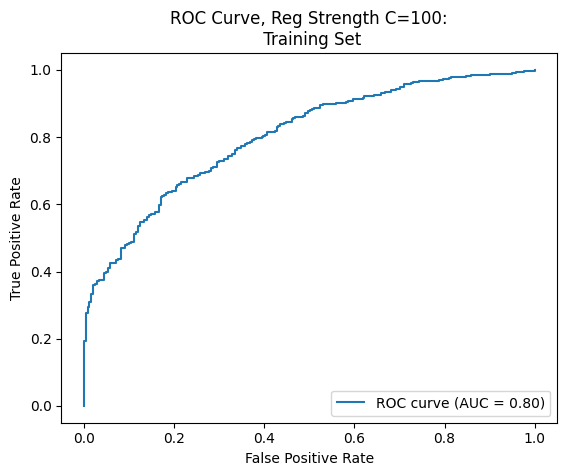

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 10000..................
Metrics on validation set:
                  precision    recall  f1-score   support

 bad credit risk       0.71      0.48      0.58        31
good credit risk       0.80      0.91      0.85        69

        accuracy                           0.78       100
       macro avg       0.76      0.70      0.71       100
    weighted avg       0.77      0.78      0.77       100

Accuracy: 0.78
Recall: 0.91
Precision: 0.8
Metrics on training set:
                  precision    recall  f1-score   support

 bad credit risk       0.66      0.44      0.53       241
good credit risk       0.79      0.90      0.84       559

        accuracy                           0.76       800
       macro avg       0.72      0.67      0.69       800
    weighted avg       0.75      0.76      0.75       8

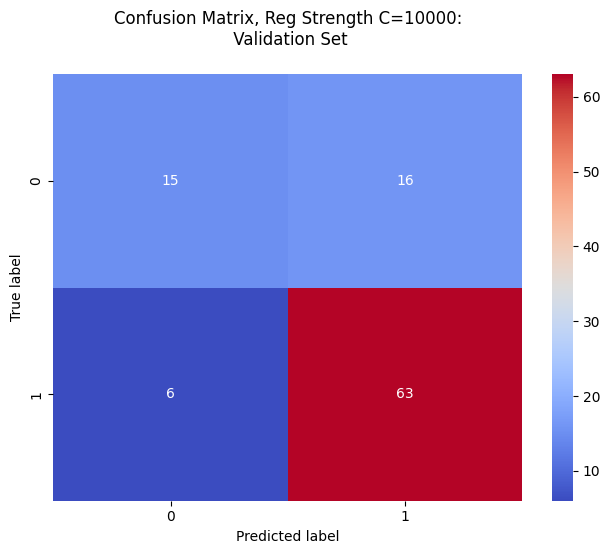

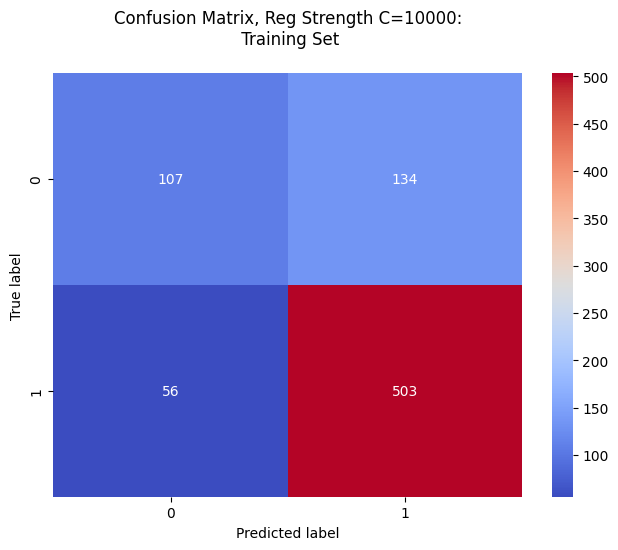

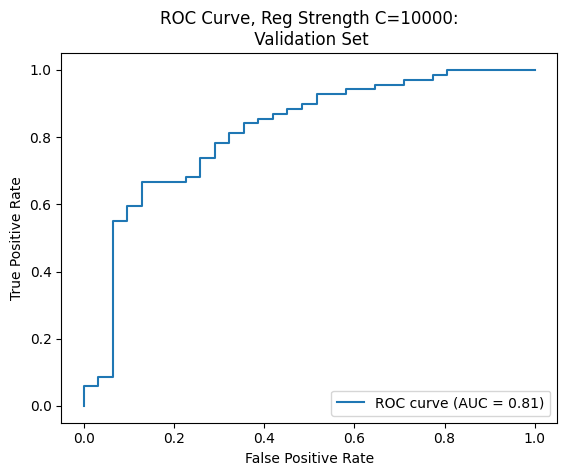

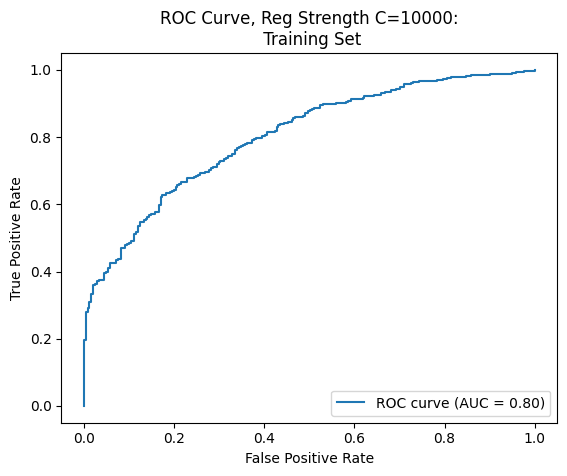

---------------------------------------------------------------------
---------------------------------------------------------------------
Trying Regularisation Inverse Strength C = 1000000..................
Metrics on validation set:
                  precision    recall  f1-score   support

 bad credit risk       0.71      0.48      0.58        31
good credit risk       0.80      0.91      0.85        69

        accuracy                           0.78       100
       macro avg       0.76      0.70      0.71       100
    weighted avg       0.77      0.78      0.77       100

Accuracy: 0.78
Recall: 0.91
Precision: 0.8
Metrics on training set:
                  precision    recall  f1-score   support

 bad credit risk       0.66      0.44      0.53       241
good credit risk       0.79      0.90      0.84       559

        accuracy                           0.76       800
       macro avg       0.72      0.67      0.69       800
    weighted avg       0.75      0.76      0.75      

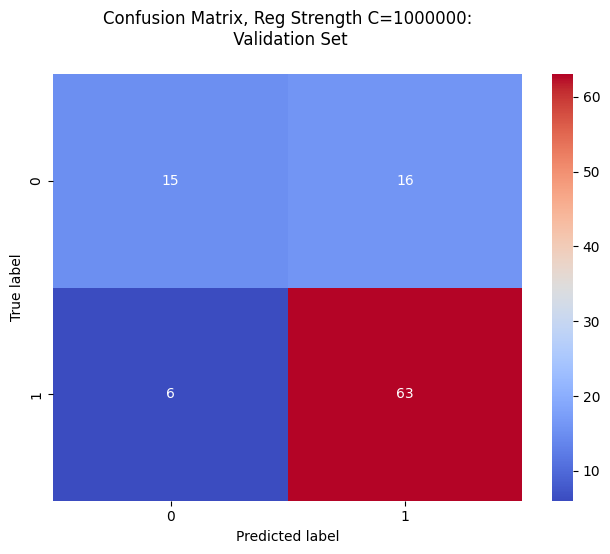

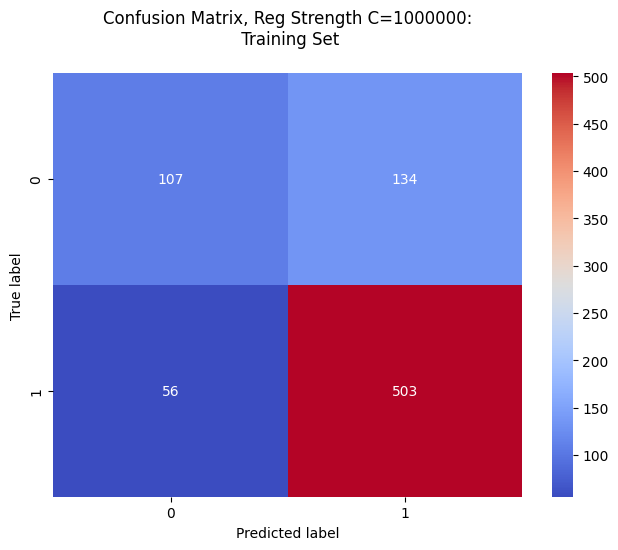

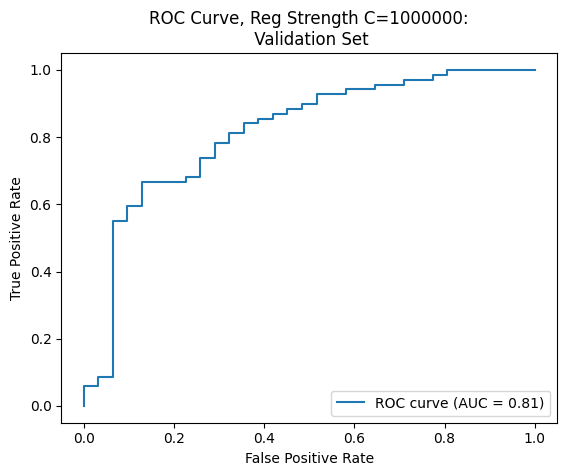

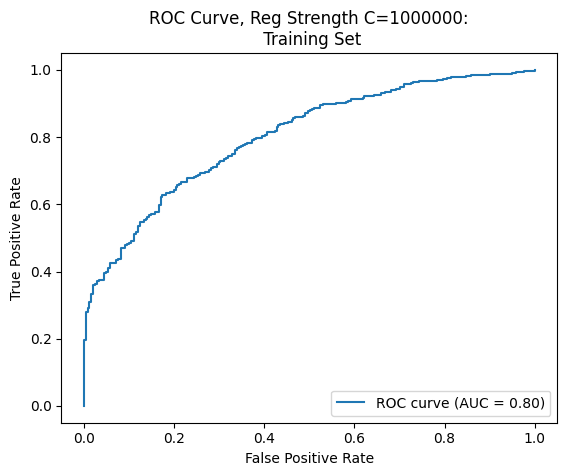

---------------------------------------------------------------------
The best reg_C is 1, with auc = 0.8143992519869098 on the validation set.


In [ ]:
# [G] Regularization (at least 6 values)

reg_C_vals = [ 10**x for x in range(-6,7,2) ]
best_reg_C = None
best_auc = -1

# Try different values for regularization strength and see how it performs using * VALIDATION * set
# At the end, choose the best and evaluate model performance on test set
for reg_C in reg_C_vals:
  print("---------------------------------------------------------------------")
  print(f"Trying Regularisation Inverse Strength C = {reg_C}..................")
  logreg_regularized = LogisticRegression(penalty='l2', C=reg_C, solver='lbfgs', max_iter=1000)
  logreg_regularized.fit(X_train, y_train)
  y_predict_regularized = logreg_regularized.predict(X_val)
  y_predict_regularized_train = logreg_regularized.predict(X_train)
  y_predict_prob_reg = logreg_regularized.predict_proba(X_val)[::, 1]
  y_predict_prob_reg_train = logreg_regularized.predict_proba(X_train)[::, 1]

  # Display metrics
  cnf_matrix_regularized = get_confusion_matrix(y_val, y_predict_regularized)
  cnf_matrix_regularized_train = get_confusion_matrix(y_train, y_predict_regularized_train)
  visualize_confusion_matrix(cnf_matrix_regularized, class_names=[0, 1], title=f'Confusion Matrix, Reg Strength C={reg_C}:\n Validation Set')
  visualize_confusion_matrix(cnf_matrix_regularized_train, class_names=[0, 1], title=f'Confusion Matrix, Reg Strength C={reg_C}:\n Training Set')

  print("Metrics on validation set:")
  display_metrics(y_val, y_predict_regularized, cnf_matrix_regularized, target_names=target_names)
  print("Metrics on training set:")
  display_metrics(y_train, y_predict_regularized_train, cnf_matrix_regularized_train, target_names=target_names)
  auc = visualize_ROC_plot(y_val, y_predict_prob_reg, class_mapping=class_mapping, title=f"ROC Curve, Reg Strength C={reg_C}:\n Validation Set")
  visualize_ROC_plot(y_train, y_predict_prob_reg_train, class_mapping=class_mapping, title=f"ROC Curve, Reg Strength C={reg_C}:\n Training Set")
  if auc > best_auc:
    best_auc = auc
    best_reg_C = reg_C
  print("---------------------------------------------------------------------")

print(f"The best reg_C is {best_reg_C}, with auc = {best_auc} on the validation set.")


                  precision    recall  f1-score   support

 bad credit risk       0.20      0.04      0.06        28
good credit risk       0.72      0.94      0.81        72

        accuracy                           0.69       100
       macro avg       0.46      0.49      0.44       100
    weighted avg       0.57      0.69      0.60       100

Accuracy: 0.69
Recall: 0.94
Precision: 0.72


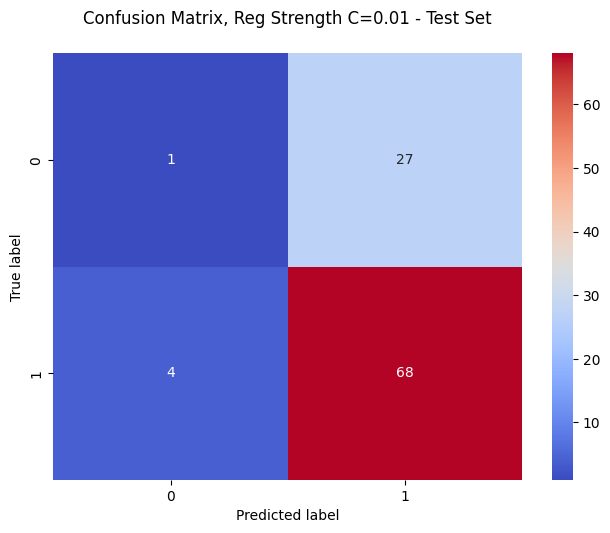

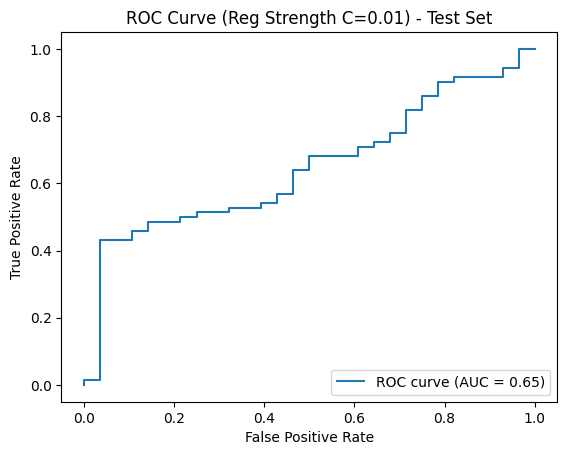

0.6478174603174603

In [ ]:
# [G] regularization - cont

# Train the logistic regression model with the best regularization strength (no feature transform)
logreg_regularized = LogisticRegression(penalty='l2', C=best_reg_C, solver='lbfgs', max_iter=1000)
logreg_regularized.fit(X_train, y_train)
y_predict_regularized = logreg_regularized.predict(X_test)

# Evaluate final performance (no feature transform)
cnf_matrix_regularized = get_confusion_matrix(y_test, y_predict_regularized)
visualize_confusion_matrix(cnf_matrix_regularized, class_names=[0, 1], title=f"Confusion Matrix, Reg Strength C={best_reg_C} - Test Set")

display_metrics(y_test, y_predict_regularized, cnf_matrix_regularized, target_names=target_names)
y_predict_prob = logreg_regularized.predict_proba(X_test)[::, 1]
visualize_ROC_plot(y_test, y_predict_prob, class_mapping=class_mapping, title=f"ROC Curve (Reg Strength C={best_reg_C}) - Test Set")


# SECTION [G] DONE ✅ (Everything Finished)

The best reg_C is 1
Final Polynomial deg 3 feature transform: 
                  precision    recall  f1-score   support

 bad credit risk       0.55      0.61      0.58        28
good credit risk       0.84      0.81      0.82        72

        accuracy                           0.75       100
       macro avg       0.69      0.71      0.70       100
    weighted avg       0.76      0.75      0.75       100

Accuracy: 0.75
Recall: 0.81
Precision: 0.84


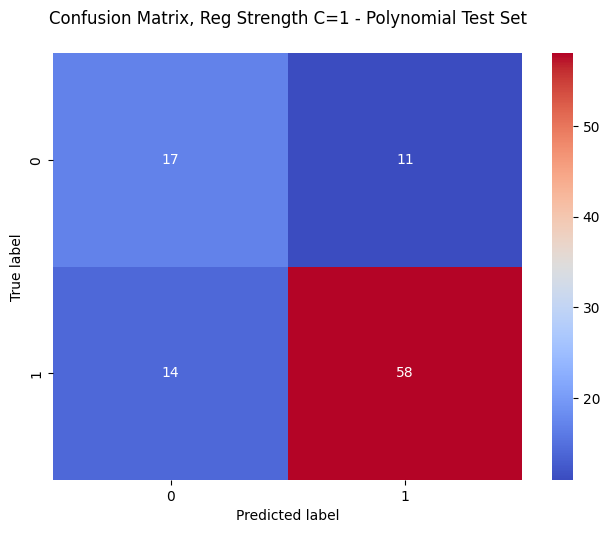

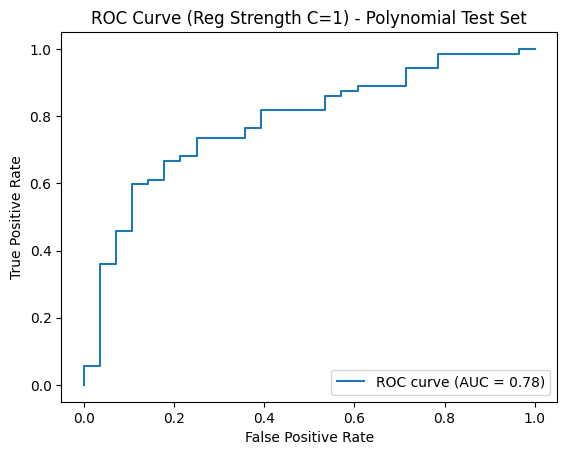

Final PCA feature transform: 
                  precision    recall  f1-score   support

 bad credit risk       0.41      0.25      0.31        28
good credit risk       0.75      0.86      0.80        72

        accuracy                           0.69       100
       macro avg       0.58      0.56      0.56       100
    weighted avg       0.65      0.69      0.66       100

Accuracy: 0.69
Recall: 0.86
Precision: 0.75


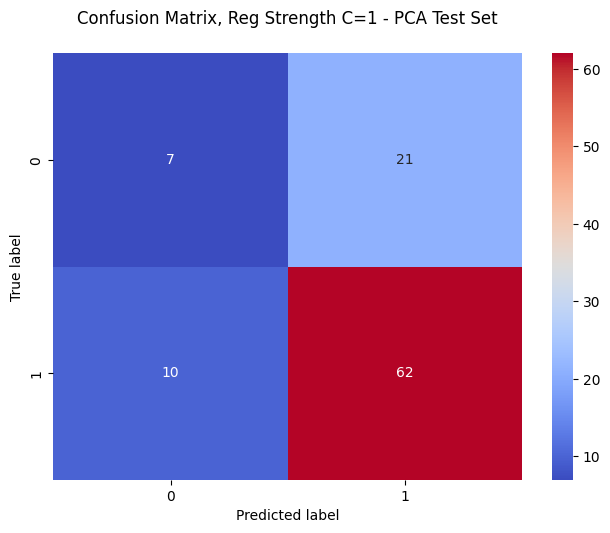

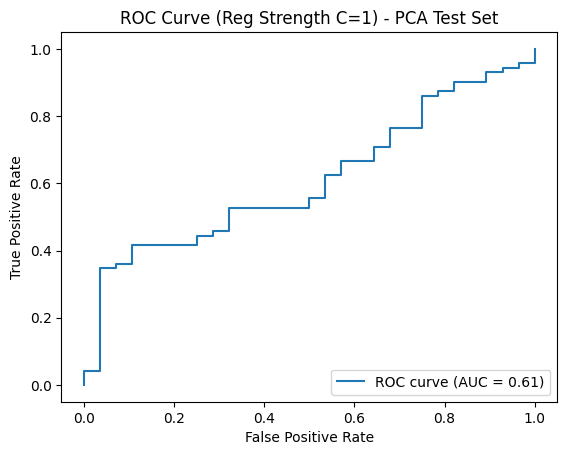

Final RBF kernel feature transform: 
                  precision    recall  f1-score   support

 bad credit risk       0.47      0.25      0.33        28
good credit risk       0.75      0.89      0.82        72

        accuracy                           0.71       100
       macro avg       0.61      0.57      0.57       100
    weighted avg       0.67      0.71      0.68       100

Accuracy: 0.71
Recall: 0.89
Precision: 0.75


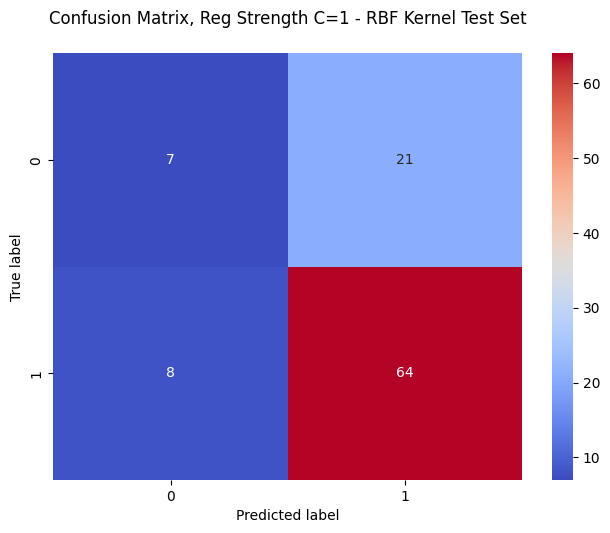

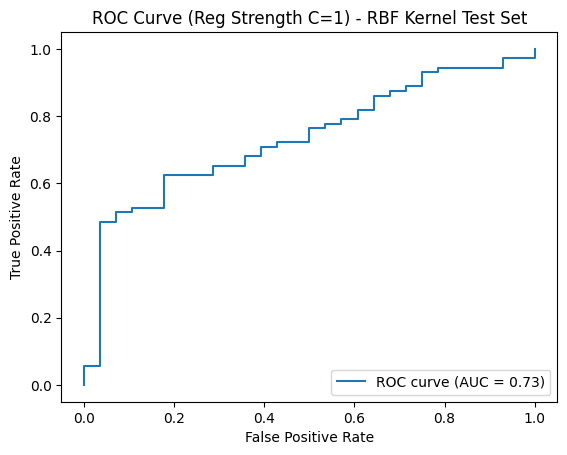

0.7341269841269841

In [ ]:
# [G] Regularization with feature transformations - trained with the best regularization param

print(f"The best reg_C is {best_reg_C}")

# [F1] Polynomial Transform
logreg_regularized_poly = LogisticRegression(penalty='l2', C=best_reg_C, solver='lbfgs', max_iter=1000)
logreg_regularized_poly.fit(X_train_polynomial, y_train)
y_predict_regularized_poly = logreg_regularized_poly.predict(X_test_polynomial)

cnf_matrix_regularized_poly = get_confusion_matrix(y_test, y_predict_regularized_poly)
visualize_confusion_matrix(cnf_matrix_regularized_poly, class_names=[0, 1], title=f"Confusion Matrix, Reg Strength C={best_reg_C} - Polynomial Test Set")

print("Final Polynomial deg 3 feature transform: ")
display_metrics(y_test, y_predict_regularized_poly, cnf_matrix_regularized_poly, target_names=target_names)
y_predict_prob_poly = logreg_regularized_poly.predict_proba(X_test_polynomial)[::, 1]
visualize_ROC_plot(y_test, y_predict_prob_poly, class_mapping=class_mapping, title=f"ROC Curve (Reg Strength C={best_reg_C}) - Polynomial Test Set")

# [F2] PCA Transform
logreg_regularized_pca = LogisticRegression(penalty='l2', C=best_reg_C, solver='lbfgs', max_iter=1000)
logreg_regularized_pca.fit(X_train_pca, y_train)
y_predict_regularized_pca = logreg_regularized_pca.predict(X_test_pca)

cnf_matrix_regularized_pca = get_confusion_matrix(y_test, y_predict_regularized_pca)
visualize_confusion_matrix(cnf_matrix_regularized_pca, class_names=[0, 1], title=f"Confusion Matrix, Reg Strength C={best_reg_C} - PCA Test Set")

print("Final PCA feature transform: ")
display_metrics(y_test, y_predict_regularized_pca, cnf_matrix_regularized_pca, target_names=target_names)
y_predict_prob_pca = logreg_regularized_pca.predict_proba(X_test_pca)[::, 1]
visualize_ROC_plot(y_test, y_predict_prob_pca, class_mapping=class_mapping, title=f"ROC Curve (Reg Strength C={best_reg_C}) - PCA Test Set")

# [F3] RBF Kernel Transform
logreg_regularized_rbf = LogisticRegression(penalty='l2', C=best_reg_C, solver='lbfgs', max_iter=1000)
logreg_regularized_rbf.fit(X_train_rbf, y_train)
y_predict_regularized_rbf = logreg_regularized_rbf.predict(X_test_rbf)

cnf_matrix_regularized_rbf = get_confusion_matrix(y_test, y_predict_regularized_rbf)
visualize_confusion_matrix(cnf_matrix_regularized_rbf, class_names=[0, 1], title=f"Confusion Matrix, Reg Strength C={best_reg_C} - RBF Kernel Test Set")

print("Final RBF kernel feature transform: ")
display_metrics(y_test, y_predict_regularized_rbf, cnf_matrix_regularized_rbf, target_names=target_names)
y_predict_prob_rbf = logreg_regularized_rbf.predict_proba(X_test_rbf)[::, 1]
visualize_ROC_plot(y_test, y_predict_prob_rbf, class_mapping=class_mapping, title=f"ROC Curve (Reg Strength C={best_reg_C}) - RBF Kernel Test Set")


In [ ]:
# Final Best
# Feature Transform: Polynomial degree 3
# reg C = 1